Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🌽 CORN — PHASE 2: DATA PREPROCESSING

Google Drive root:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)

Final verified dataset:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/1st Raw_Data/Corn/Final_Combined

Preprocessing output folder:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing/Corn

Class mapping:
0 -> Healthy
1 -> Common_Rust
2 -> Northern_Leaf_Blight

CHECKING FINAL VERIFIED DATASET
Healthy: 595 images
Common_Rust: 600 images
Northern_Leaf_Blight: 600 images

Total verified images found:
1795

Class distribution:


,images
class,
Healthy,595
Common_Rust,600
Northern_Leaf_Blight,600



PASS: Final verified dataset contains all required classes.

STRATIFIED DATASET SPLIT

Train: 1256
Validation: 269
Test: 270
Total: 1795


class,Common_Rust,Healthy,Northern_Leaf_Blight
split,,,
test,90,90,90
train,420,416,420
validation,90,89,90



PREPROCESSING TRAINING DATA


...


PREPROCESSING VALIDATION DATA


Validation images:   0%|          | 0/269 [00:00<?, ?it/s]


PREPROCESSING TEST DATA


Test images:   0%|          | 0/270 [00:00<?, ?it/s]


PREPROCESSED DATA VERIFICATION

X_train shape: (1256, 224, 224, 3)
X_val shape: (269, 224, 224, 3)
X_test shape: (270, 224, 224, 3)

y_train shape: (1256,)
y_val shape: (269,)
y_test shape: (270,)

Data type: uint8
Pixel range: 0 to 255

PASS: Image shape = 224 × 224 × 3
PASS: All images converted to RGB
PASS: Pixel data stored as uint8 [0,255]
PASS: Train/Validation/Test counts match
PASS: Total processed images = 1,795

SPLIT LEAKAGE CHECK
Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0

PASS: No image appears in more than one split.

Processed dataset saved:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing/Corn/corn_processed_data.npz

Split manifest saved:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing/Corn/corn_split_manifest.csv

Class mapping saved:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing/Corn/corn_class_mapping.csv

Preprocessing s

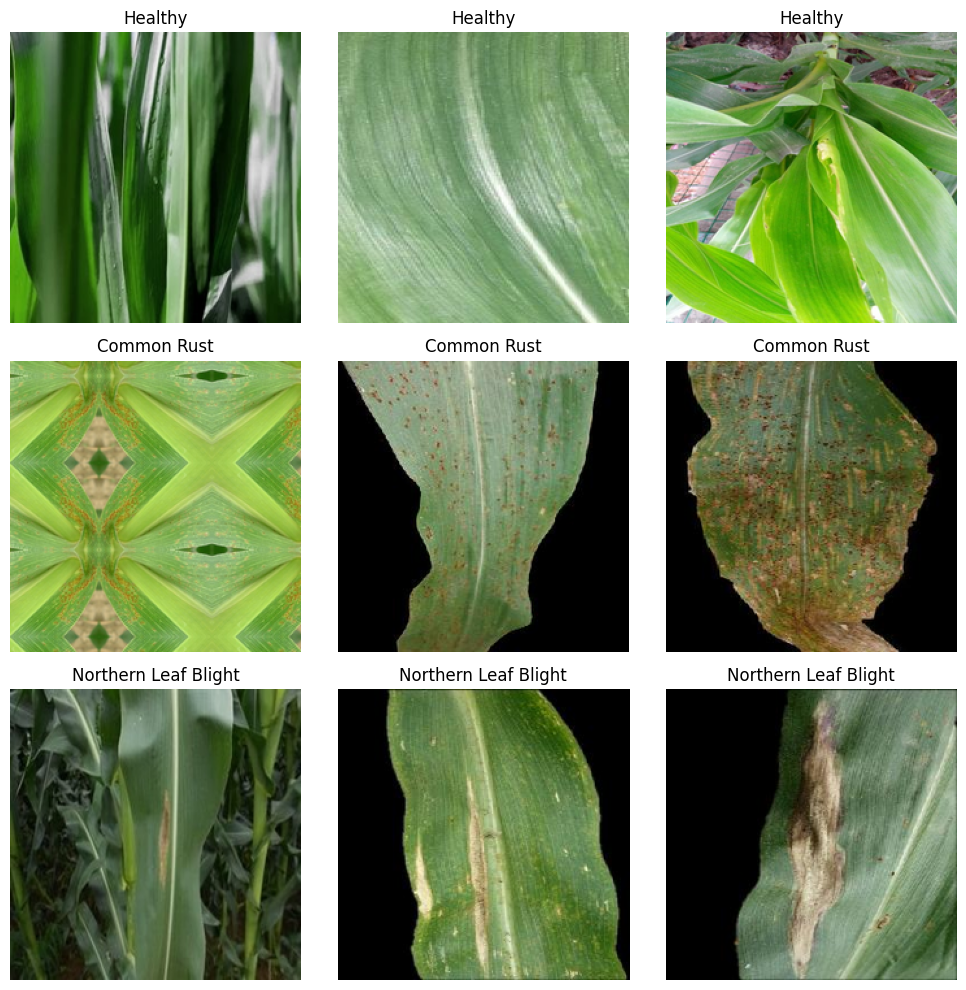


🌽 CORN — PHASE 2 PREPROCESSING FINAL AUDIT
PASS | Final dataset found
PASS | Expected total = 1795
PASS | All 3 classes present
PASS | 224x224 RGB
PASS | uint8 [0,255]
PASS | No split leakage
PASS | Processed NPZ saved
PASS | Split manifest saved

🎉 CORN PHASE 2 — PREPROCESSING: PASS

Dataset successfully prepared.
Total images: 1795
Train: 1256
Validation: 269
Test: 270

Image format: 224 × 224 RGB
Storage: uint8 [0,255]
Model preprocessing: MobileNetV2 preprocess_input

Next step: CORN MODEL TRAINING


In [2]:
# ==============================================================================================
# 🌽 CORN — PHASE 2: DATA PREPROCESSING
# ==============================================================================================
# Strategy:
# 1. Mount Google Drive
# 2. Load final verified Corn dataset from Google Drive
# 3. Verify 3 classes and 1,795 images
# 4. Convert all images to RGB
# 5. Resize all images to 224 x 224
# 6. Create stratified 70% Train / 15% Validation / 15% Test split
# 7. Test data remains completely separate from training
# 8. Save processed arrays + split manifest + class mapping
# 9. Ready for MobileNetV2 transfer-learning model in Phase 2
# ==============================================================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

print("=" * 90)
print("🌽 CORN — PHASE 2: DATA PREPROCESSING")
print("=" * 90)

# ==============================================================================================
# 1. PATHS
# ==============================================================================================

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"
)

RAW_ROOT = DRIVE_ROOT / "1st Raw_Data" / "Corn"

# IMPORTANT:
# Final verified dataset is stored inside Google Drive
FINAL_ROOT = RAW_ROOT / "Final_Combined"

PREPROCESS_ROOT = (
    DRIVE_ROOT /
    "3rd Preprocessing" /
    "Corn"
)

PREPROCESS_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("\nGoogle Drive root:")
print(DRIVE_ROOT)

print("\nFinal verified dataset:")
print(FINAL_ROOT)

print("\nPreprocessing output folder:")
print(PREPROCESS_ROOT)

# ==============================================================================================
# 2. REQUIRED CLASSES
# ==============================================================================================

FINAL_CLASSES = [
    "Healthy",
    "Common_Rust",
    "Northern_Leaf_Blight"
]

CLASS_TO_INDEX = {
    cls: idx
    for idx, cls in enumerate(FINAL_CLASSES)
}

INDEX_TO_CLASS = {
    idx: cls
    for cls, idx in CLASS_TO_INDEX.items()
}

print("\nClass mapping:")
for idx, cls in INDEX_TO_CLASS.items():
    print(f"{idx} -> {cls}")

# ==============================================================================================
# 3. VERIFY FINAL DATASET PATH
# ==============================================================================================

if not FINAL_ROOT.exists():

    raise RuntimeError(
        "\nSTOP: Final verified Corn dataset was not found.\n"
        f"Expected location:\n{FINAL_ROOT}\n\n"
        "Check that Google Drive is mounted and "
        "Final_Combined exists inside 1st Raw_Data/Corn."
    )

print("\n" + "=" * 90)
print("CHECKING FINAL VERIFIED DATASET")
print("=" * 90)

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

# ==============================================================================================
# 4. COLLECT IMAGE FILES
# ==============================================================================================

records = []

for cls in FINAL_CLASSES:

    class_folder = FINAL_ROOT / cls

    if not class_folder.exists():

        raise RuntimeError(
            f"STOP: Required class folder missing:\n{class_folder}"
        )

    files = [
        f
        for f in class_folder.rglob("*")
        if f.is_file()
        and f.suffix.lower() in VALID_EXTENSIONS
    ]

    print(
        f"{cls}: {len(files)} images"
    )

    for file in files:

        records.append({
            "filepath": str(file),
            "class": cls,
            "label": CLASS_TO_INDEX[cls]
        })

dataset_df = pd.DataFrame(records)

print("\nTotal verified images found:")
print(len(dataset_df))

# ==============================================================================================
# 5. DATASET COUNT VERIFICATION
# ==============================================================================================

class_distribution = (
    dataset_df["class"]
    .value_counts()
    .reindex(FINAL_CLASSES)
)

print("\nClass distribution:")
display(
    class_distribution.to_frame("images")
)

EXPECTED_TOTAL = 1795

if len(dataset_df) != EXPECTED_TOTAL:

    raise RuntimeError(
        f"\nSTOP: Expected {EXPECTED_TOTAL} verified images, "
        f"but found {len(dataset_df)}."
    )

if class_distribution.isna().any():

    raise RuntimeError(
        "STOP: One or more required classes are missing."
    )

if not all(class_distribution > 0):

    raise RuntimeError(
        "STOP: One or more classes contain zero images."
    )

print(
    "\nPASS: Final verified dataset contains "
    "all required classes."
)

# ==============================================================================================
# 6. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ==============================================================================================
#
# First:
#       70% Train
#       30% Temporary
#
# Then temporary:
#       50% Validation
#       50% Test
#
# Final:
#       approximately 70% Train
#       approximately 15% Validation
#       approximately 15% Test
#
# Stratification guarantees class representation in all splits.
# ==============================================================================================

SEED = 42

train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    stratify=dataset_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Add split column
train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

# ==============================================================================================
# 7. SPLIT SUMMARY
# ==============================================================================================

print("\n" + "=" * 90)
print("STRATIFIED DATASET SPLIT")
print("=" * 90)

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(split_df))

split_summary = (
    split_df
    .groupby(["split", "class"])
    .size()
    .unstack(fill_value=0)
)

display(split_summary)

# ==============================================================================================
# 8. PREPROCESSING FUNCTION
# ==============================================================================================

IMAGE_SIZE = (224, 224)

def preprocess_image(file_path):

    try:

        with Image.open(file_path) as img:

            # Convert every image to RGB
            img = img.convert("RGB")

            # Resize to 224 x 224
            img = img.resize(
                IMAGE_SIZE,
                Image.Resampling.LANCZOS
            )

            # Keep pixel values 0–255 as uint8.
            # MobileNetV2 preprocessing will be applied
            # inside the model/training pipeline.
            image_array = np.asarray(
                img,
                dtype=np.uint8
            )

        # Final shape check
        if image_array.shape != (224, 224, 3):

            raise ValueError(
                f"Unexpected image shape: "
                f"{image_array.shape}"
            )

        return image_array

    except Exception as e:

        raise RuntimeError(
            f"Image preprocessing failed:\n"
            f"{file_path}\n"
            f"Error: {e}"
        )

# ==============================================================================================
# 9. PROCESS TRAINING DATA
# ==============================================================================================

print("\n" + "=" * 90)
print("PREPROCESSING TRAINING DATA")
print("=" * 90)

X_train = np.empty(
    (len(train_df), 224, 224, 3),
    dtype=np.uint8
)

y_train = train_df["label"].to_numpy(
    dtype=np.int64
)

for i, file_path in enumerate(
    tqdm(
        train_df["filepath"],
        desc="Train images"
    )
):

    X_train[i] = preprocess_image(
        file_path
    )

# ==============================================================================================
# 10. PROCESS VALIDATION DATA
# ==============================================================================================

print("\n" + "=" * 90)
print("PREPROCESSING VALIDATION DATA")
print("=" * 90)

X_val = np.empty(
    (len(val_df), 224, 224, 3),
    dtype=np.uint8
)

y_val = val_df["label"].to_numpy(
    dtype=np.int64
)

for i, file_path in enumerate(
    tqdm(
        val_df["filepath"],
        desc="Validation images"
    )
):

    X_val[i] = preprocess_image(
        file_path
    )

# ==============================================================================================
# 11. PROCESS TEST DATA
# ==============================================================================================

print("\n" + "=" * 90)
print("PREPROCESSING TEST DATA")
print("=" * 90)

X_test = np.empty(
    (len(test_df), 224, 224, 3),
    dtype=np.uint8
)

y_test = test_df["label"].to_numpy(
    dtype=np.int64
)

for i, file_path in enumerate(
    tqdm(
        test_df["filepath"],
        desc="Test images"
    )
):

    X_test[i] = preprocess_image(
        file_path
    )

# ==============================================================================================
# 12. FINAL ARRAY VERIFICATION
# ==============================================================================================

print("\n" + "=" * 90)
print("PREPROCESSED DATA VERIFICATION")
print("=" * 90)

print("\nX_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print("\nData type:", X_train.dtype)
print(
    "Pixel range:",
    X_train.min(),
    "to",
    X_train.max()
)

# Shape checks
assert X_train.shape[1:] == (224, 224, 3)
assert X_val.shape[1:] == (224, 224, 3)
assert X_test.shape[1:] == (224, 224, 3)

# RGB checks
assert X_train.dtype == np.uint8
assert X_val.dtype == np.uint8
assert X_test.dtype == np.uint8

# Count checks
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

assert (
    len(X_train)
    + len(X_val)
    + len(X_test)
    == EXPECTED_TOTAL
)

print("\nPASS: Image shape = 224 × 224 × 3")
print("PASS: All images converted to RGB")
print("PASS: Pixel data stored as uint8 [0,255]")
print("PASS: Train/Validation/Test counts match")
print("PASS: Total processed images = 1,795")

# ==============================================================================================
# 13. VERIFY NO FILE OVERLAP BETWEEN SPLITS
# ==============================================================================================

train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

train_val_overlap = train_paths.intersection(val_paths)
train_test_overlap = train_paths.intersection(test_paths)
val_test_overlap = val_paths.intersection(test_paths)

print("\n" + "=" * 90)
print("SPLIT LEAKAGE CHECK")
print("=" * 90)

print(
    "Train ↔ Validation overlap:",
    len(train_val_overlap)
)

print(
    "Train ↔ Test overlap:",
    len(train_test_overlap)
)

print(
    "Validation ↔ Test overlap:",
    len(val_test_overlap)
)

if (
    len(train_val_overlap) == 0
    and
    len(train_test_overlap) == 0
    and
    len(val_test_overlap) == 0
):

    print(
        "\nPASS: No image appears in more than one split."
    )

else:

    raise RuntimeError(
        "STOP: Dataset leakage detected between splits."
    )

# ==============================================================================================
# 14. SAVE PROCESSED DATASET
# ==============================================================================================

npz_path = (
    PREPROCESS_ROOT /
    "corn_processed_data.npz"
)

np.savez_compressed(
    npz_path,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

print("\nProcessed dataset saved:")
print(npz_path)

# ==============================================================================================
# 15. SAVE SPLIT MANIFEST
# ==============================================================================================

manifest_path = (
    PREPROCESS_ROOT /
    "corn_split_manifest.csv"
)

split_df.to_csv(
    manifest_path,
    index=False
)

print("\nSplit manifest saved:")
print(manifest_path)

# ==============================================================================================
# 16. SAVE CLASS MAPPING
# ==============================================================================================

class_mapping_df = pd.DataFrame({
    "label": list(INDEX_TO_CLASS.keys()),
    "class": list(INDEX_TO_CLASS.values())
})

mapping_path = (
    PREPROCESS_ROOT /
    "corn_class_mapping.csv"
)

class_mapping_df.to_csv(
    mapping_path,
    index=False
)

print("\nClass mapping saved:")
print(mapping_path)

# ==============================================================================================
# 17. SAVE PREPROCESSING SUMMARY
# ==============================================================================================

summary_data = {
    "plant": ["Corn"],
    "total_images": [len(split_df)],
    "train_images": [len(train_df)],
    "validation_images": [len(val_df)],
    "test_images": [len(test_df)],
    "image_width": [224],
    "image_height": [224],
    "channels": [3],
    "color_mode": ["RGB"],
    "dtype": ["uint8"],
    "pixel_range": ["0-255"],
    "split_method": ["Stratified"],
    "train_ratio": ["70%"],
    "validation_ratio": ["15%"],
    "test_ratio": ["15%"],
    "random_seed": [SEED],
    "classes": [", ".join(FINAL_CLASSES)],
    "model_preprocessing": ["MobileNetV2 preprocess_input during training"]
}

preprocessing_summary_df = pd.DataFrame(
    summary_data
)

summary_path = (
    PREPROCESS_ROOT /
    "Corn_Preprocessing_Summary.csv"
)

preprocessing_summary_df.to_csv(
    summary_path,
    index=False
)

print("\nPreprocessing summary saved:")
print(summary_path)

# ==============================================================================================
# 18. VISUAL SAMPLE CHECK
# ==============================================================================================

print("\n" + "=" * 90)
print("PREPROCESSED IMAGE SAMPLE CHECK")
print("=" * 90)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(10, 10)
)

for row, cls in enumerate(FINAL_CLASSES):

    class_indices = np.where(
        y_train == CLASS_TO_INDEX[cls]
    )[0]

    sample_indices = class_indices[:3]

    for col, idx in enumerate(sample_indices):

        axes[row, col].imshow(
            X_train[idx]
        )

        axes[row, col].set_title(
            cls.replace("_", " ")
        )

        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# ==============================================================================================
# 19. FINAL PHASE-2 PREPROCESSING AUDIT
# ==============================================================================================

print("\n" + "=" * 90)
print("🌽 CORN — PHASE 2 PREPROCESSING FINAL AUDIT")
print("=" * 90)

checks = {}

checks["Final dataset found"] = FINAL_ROOT.exists()

checks["Expected total = 1795"] = (
    len(split_df) == 1795
)

checks["All 3 classes present"] = (
    set(split_df["class"].unique())
    == set(FINAL_CLASSES)
)

checks["224x224 RGB"] = (
    X_train.shape[1:] == (224, 224, 3)
    and
    X_val.shape[1:] == (224, 224, 3)
    and
    X_test.shape[1:] == (224, 224, 3)
)

checks["uint8 [0,255]"] = (
    X_train.dtype == np.uint8
    and
    X_val.dtype == np.uint8
    and
    X_test.dtype == np.uint8
    and
    X_train.min() >= 0
    and
    X_train.max() <= 255
)

checks["No split leakage"] = (
    len(train_val_overlap) == 0
    and
    len(train_test_overlap) == 0
    and
    len(val_test_overlap) == 0
)

checks["Processed NPZ saved"] = (
    npz_path.exists()
)

checks["Split manifest saved"] = (
    manifest_path.exists()
)

# Display results

for check, result in checks.items():

    print(
        f"{'PASS' if result else 'FAIL'} | {check}"
    )

print("\n" + "=" * 90)

if all(checks.values()):

    print("🎉 CORN PHASE 2 — PREPROCESSING: PASS")
    print("\nDataset successfully prepared.")
    print(
        f"Total images: {len(split_df)}"
    )
    print(
        f"Train: {len(train_df)}"
    )
    print(
        f"Validation: {len(val_df)}"
    )
    print(
        f"Test: {len(test_df)}"
    )
    print(
        "\nImage format: 224 × 224 RGB"
    )
    print(
        "Storage: uint8 [0,255]"
    )
    print(
        "Model preprocessing: MobileNetV2 preprocess_input"
    )
    print(
        "\nNext step: CORN MODEL TRAINING"
    )

else:

    print(
        "⚠️ CORN PHASE 2 — PREPROCESSING: NOT READY"
    )

print("=" * 90)